# Imports

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" # Filters out info and warning messages

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix

from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import InceptionV3, ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Concatenate, Embedding, Flatten
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

E0000 00:00:1767220731.905727      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767220731.959533      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767220732.418102      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767220732.418139      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767220732.418142      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767220732.418144      55 computation_placer.cc:177] computation placer already registered. Please check linka

# Dataset Preparation

In [2]:
# Constants for dataset path, random seed for reproducible results, model training constants
DATA_ROOT = "/kaggle/input/rsna-bone-age"
CSV_PATH = f"{DATA_ROOT}/boneage-training-dataset.csv"
IMG_DIR  = f"{DATA_ROOT}/boneage-training-dataset/boneage-training-dataset"
RANDOM_SEED = 5
N_BINS = 10
IMG_SIZE = 256
BATCH_SIZE = 16
K_FOLDS = 5
EPOCHS_PER_FOLD = 8

## Load CSV Dataset

In [3]:
df = pd.read_csv(CSV_PATH)

print("Initial CSV shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())


Initial CSV shape: (12611, 3)

Columns: ['id', 'boneage', 'male']

First 5 rows:


,id,boneage,male
0,1377,180,False
1,1378,12,False
2,1379,94,False
3,1380,120,True
4,1381,82,False


## Encoding Male Column (T -> 0, F -> 1)

In [4]:
df["male"] = df["male"].map({True: 0, False: 1})

print("\nSex encoding check:")
print(df["male"].value_counts())



Sex encoding check:
male
0    6833
1    5778
Name: count, dtype: int64


## Building Image Paths As A Column In CSV Dataframe

In [5]:
df["path"] = df["id"].apply(lambda x: os.path.join(IMG_DIR, f"{x}.png"))

print(df["path"][1])
print(df.columns)

/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/1378.png
Index(['id', 'boneage', 'male', 'path'], dtype='object')


## Clean Up Dataframe Columns

In [6]:
df = df[["path", "boneage", "male"]]

print("\nFinal dataframe shape:", df.shape)
display(df.head())



Final dataframe shape: (12611, 3)


,path,boneage,male
0,/kaggle/input/rsna-bone-age/boneage-training-d...,180,1
1,/kaggle/input/rsna-bone-age/boneage-training-d...,12,1
2,/kaggle/input/rsna-bone-age/boneage-training-d...,94,1
3,/kaggle/input/rsna-bone-age/boneage-training-d...,120,0
4,/kaggle/input/rsna-bone-age/boneage-training-d...,82,1


##  Distributed Bone Ages (Which Are In Months) Into 10 Bins

In [7]:

df["age_bin"], bin_edges = pd.qcut(df["boneage"], q=N_BINS, duplicates="drop", retbins=True)

# Create readable labels like "0-96m", "96-120m"
bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}m" for i in range(len(bin_edges)-1)]

print(f"Generated Data Bins: {bin_labels}")
print("\nAge bin distribution:")
print(df["age_bin"].value_counts().sort_index())


Generated Data Bins: ['1-69m', '69-94m', '94-106m', '106-120m', '120-132m', '132-144m', '144-156m', '156-162m', '162-168m', '168-228m']

Age bin distribution:
age_bin
(0.999, 69.0]     1328
(69.0, 94.0]      1620
(94.0, 106.0]      895
(106.0, 120.0]    1437
(120.0, 132.0]    1302
(132.0, 144.0]    1238
(144.0, 156.0]    1856
(156.0, 162.0]     759
(162.0, 168.0]     967
(168.0, 228.0]    1209
Name: count, dtype: int64


## Combining Age & Sex For Stratification

In [8]:
df["strata"] = df["age_bin"].astype(str) + "_sex_" + df["male"].astype(str)

print("\nStrata examples:")
display(df[["boneage", "male", "strata"]].head())


Strata examples:


,boneage,male,strata
0,180,1,"(168.0, 228.0]_sex_1"
1,12,1,"(0.999, 69.0]_sex_1"
2,94,1,"(69.0, 94.0]_sex_1"
3,120,0,"(106.0, 120.0]_sex_0"
4,82,1,"(69.0, 94.0]_sex_1"


## Splitting Dataset Into 85% Train & 15% Test

In [9]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["strata"]
)

print("Train size:", train_df.shape)
print("Test size :", test_df.shape)

Train size: (10719, 5)
Test size : (1892, 5)


## Dataset Distribution Check

/tmp/ipykernel_55/3967944232.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Female (0)', 'Male (1)'], fontsize=12)


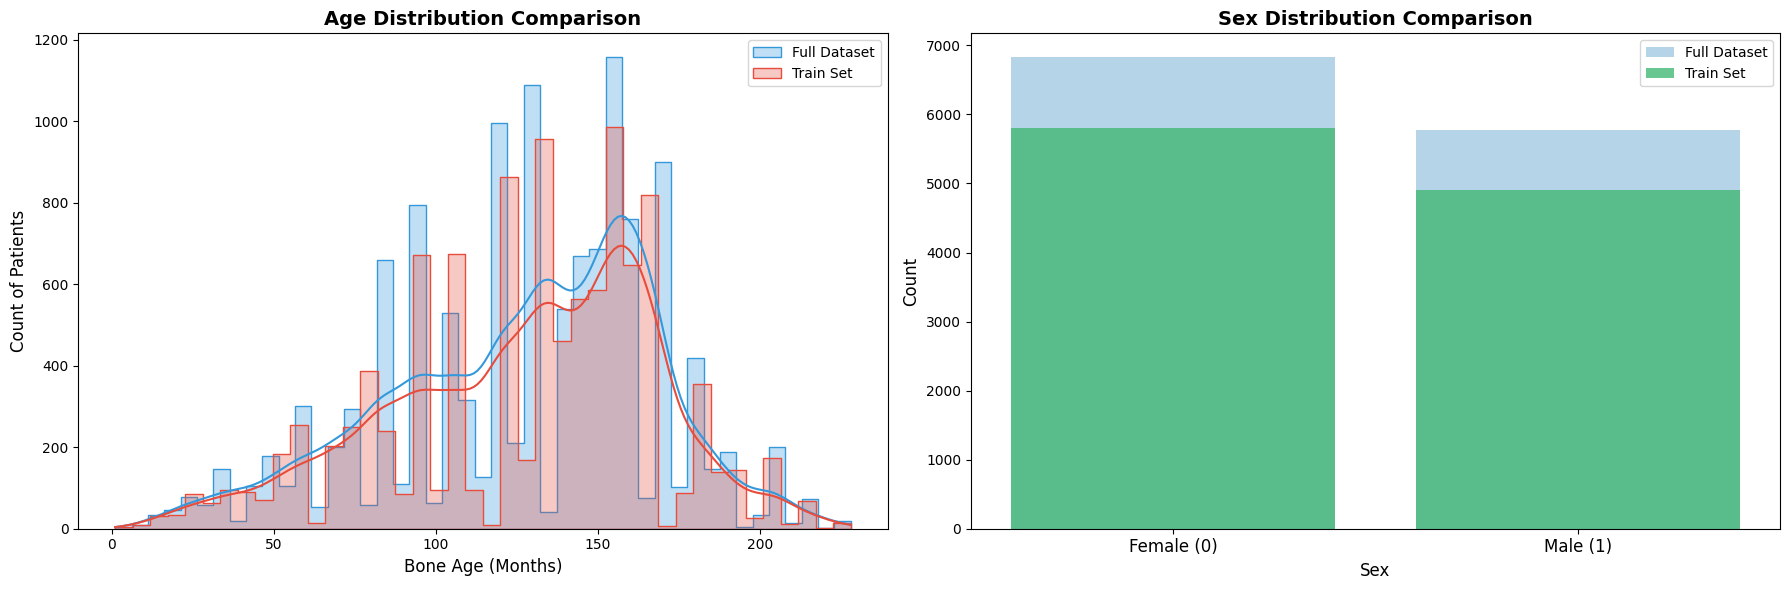


Sex distribution:
Full dataset:
male
0    0.541829
1    0.458171
Name: proportion, dtype: float64

Train:
male
0    0.541748
1    0.458252
Name: proportion, dtype: float64

Test:
male
0    0.542283
1    0.457717
Name: proportion, dtype: float64

Bone age statistics:
Full dataset:
 count    12611.000000
mean       127.320752
std         41.182021
min          1.000000
25%         96.000000
50%        132.000000
75%        156.000000
max        228.000000
Name: boneage, dtype: float64

Train:
 count    10719.000000
mean       127.322418
std         41.216811
min          1.000000
25%         96.000000
50%        132.000000
75%        156.000000
max        228.000000
Name: boneage, dtype: float64

Test:
 count    1892.000000
mean      127.311311
std        40.995219
min        12.000000
25%        96.000000
50%       132.000000
75%       156.000000
max       228.000000
Name: boneage, dtype: float64


In [ ]:
def plot_distributions(full_df, train_df):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot 1: Age Distribution
    sns.histplot(full_df['boneage'], kde=True, ax=axes[0], color='#3498db', label='Full Dataset', element="step", alpha=0.3)
    sns.histplot(train_df['boneage'], kde=True, ax=axes[0], color='#e74c3c', label='Train Set', element="step", alpha=0.3)
    
    axes[0].set_title("Age Distribution Comparison", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Bone Age (Months)", fontsize=12)
    axes[0].set_ylabel("Count of Patients", fontsize=12)
    axes[0].legend()
    
    # Plot 2: Sex Distribution
    sns.countplot(x='male', data=full_df, ax=axes[1], color='#3498db', alpha=0.4, label='Full Dataset')
    sns.countplot(x='male', data=train_df, ax=axes[1], color='#2ecc71', alpha=0.8, label='Train Set')
    
    axes[1].set_title("Sex Distribution Comparison", fontsize=14, fontweight='bold')
    axes[1].set_xticklabels(['Female (0)', 'Male (1)'], fontsize=12)
    axes[1].set_xlabel("Sex", fontsize=12)
    axes[1].set_ylabel("Count", fontsize=12)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_distributions(df, train_df)

# Print Statistics
print("\nSex distribution:")
print("Full dataset:")
print(df["male"].value_counts(normalize=True))

print("\nTrain:")
print(train_df["male"].value_counts(normalize=True))

print("\nTest:")
print(test_df["male"].value_counts(normalize=True))

print("\nBone age statistics:")
print("Full dataset:\n", df["boneage"].describe())
print("\nTrain:\n", train_df["boneage"].describe())
print("\nTest:\n", test_df["boneage"].describe())

# Age Normalization & Denormalization Helper Functions

In [11]:
age_mean = train_df["boneage"].mean()
age_std  = train_df["boneage"].std()

# Converts the actual bone age (months) to normalized age
def normalize_age(age, age_mean, age_std):
    return (age - age_mean) / age_std

# Converts the model's normalized output back to the actual bone age (months).
def denormalize_age(normalized_pred, age_std, age_mean):
    return (normalized_pred * age_std) + age_mean


# Images Augmentation Helper Function 

In [12]:
# Applies medically appropriate data augmentations to X-ray image preserving anatomical correctness
def augment_image(img):
    rows, cols = img.shape
    
    # Rotation is clipped to +-12 degrees
    angle = random.uniform(-12.0, 12.0)
    rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, scale=1.0)
    img = cv2.warpAffine(
        img, 
        rotation_matrix, 
        (cols, rows), 
        flags=cv2.INTER_LINEAR, 
        borderMode=cv2.BORDER_REFLECT_101
    )
    
    # Translation is clipped to +-5%
    x_shift = random.uniform(-0.05, 0.05) * cols
    y_shift = random.uniform(-0.05,0.05) * rows
    translation_matrix = np.float32([[1, 0, x_shift], [0, 1, y_shift]])
    img = cv2.warpAffine(
        img, 
        translation_matrix, 
        (cols, rows), 
        flags=cv2.INTER_LINEAR, 
        borderMode=cv2.BORDER_REFLECT_101
    )
    
    # Exposure
    contrast = random.uniform(0.9, 1.1)
    brightness = random.uniform(-10, 10)
    img = cv2.convertScaleAbs(img, alpha=contrast, beta=brightness)
    
    return img

# Image Processing Function Which Loads Image And Applies Augmentation If Training

In [13]:
# Preproccessing pipeline for hand X-ray image
def process_image_file(path_str, augment=False):
    # TensorFlow passes paths as bytes
    path = path_str.decode("utf-8")
    
    # Load grayscale image
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    
    # Apply Contrast Limited Adaptive Histogram Equalization to make bone pop more clearly
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    
    # Data augmentation for training dataset only
    if augment:
      img = augment_image(img)
    
    # Image resizing that preserves the image's aspect-ratio
    h, w = img.shape
    scale = IMG_SIZE / max(h, w)

    new_w = int(w * scale)
    new_h = int(h * scale)
    
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    
    # Padding
    delta_w = IMG_SIZE - new_w
    delta_h = IMG_SIZE - new_h
    
    top = delta_h // 2
    bottom = delta_h - top
    left = delta_w // 2
    right = delta_w - left
    
    img = cv2.copyMakeBorder(img, top, bottom, left, right, borderType=cv2.BORDER_CONSTANT, value=0)
    
    # Normalize and expand image channels to 3
    img = img.astype(np.float32) / 255.0
    img = np.stack((img,) * 3, axis=-1)
    
    return img


# TensorFlow Dataset Creation Helper Function

In [ ]:
# Constructs an optimized TensorFlow Dataset for bone age estimation, supporting multi-input models (image + gender)
def create_dataset(df, training=False):
    # Extract dataset columns
    paths = df["path"].values
    genders = df["male"].values.astype(np.float32)   # 0 = Female, 1 = Male
    
    # Age normalization
    boneages = df["boneage"].values.astype(np.float32)
    age_mean = df["boneage"].mean()
    age_std = df["boneage"].std()
    ages = normalize_age(boneages, age_mean, age_std)

    # Create base dataset
    dataset = tf.data.Dataset.from_tensor_slices((paths, genders, ages))

    # Wrapper to bridge TensorFlow Graph and Python OpenCV Code
    def tf_py_mapper(path, gender, age):
        img = tf.numpy_function(
            func=lambda p: process_image_file(p, augment=training),
            inp=[path], 
            Tout=tf.float32
        )
        img.set_shape([IMG_SIZE, IMG_SIZE, 3]) # Crucial for memory optimization as image size constant
        return ((img, gender), age)
        
    
    # Map and optimize our dataset
    dataset = dataset.map(tf_py_mapper, num_parallel_calls=tf.data.AUTOTUNE)
    
    if training:
        dataset = dataset.shuffle(buffer_size=1000)
    
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Image Preprocessing & TF Dataset Creation Tests

In [15]:
print("initializing pipelines...")

# Create Training Pipeline (Augmentation = ON)
train_ds = create_dataset(train_df, training=True)

# Create Validation Pipeline (Augmentation = OFF)
val_ds = create_dataset(test_df, training=False)

print("✅ Pipelines created successfully.")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")

# Grab 1 batch to verify shapes
for (images, genders), ages in train_ds.take(1):
    print(f"\nTest Batch Output:")
    print(f"Images Shape : {images.shape}  (should be {BATCH_SIZE}, {IMG_SIZE}, {IMG_SIZE}, 3)")
    print(f"Gender Shape : {genders.shape} (should be {BATCH_SIZE},)")
    print(f"Age Labels   : {ages.shape}    (should be {BATCH_SIZE},)")
    break

initializing pipelines...


I0000 00:00:1767220746.228697      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767220746.232550      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Pipelines created successfully.
Batch Size: 16
Image Size: 256x256

Test Batch Output:
Images Shape : (16, 256, 256, 3)  (should be 16, 256, 256, 3)
Gender Shape : (16,) (should be 16,)
Age Labels   : (16,)    (should be 16,)


In [16]:
# Shows raw image vs. processed output (with and without augmentation).
def test_pipeline_visual_sanity(image_path: str):
    # Load raw image
    raw = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    assert raw is not None, "❌ Image could not be loaded"

    # Process without augmentation (validation mode)
    processed_no_aug = process_image_file(image_path.encode("utf-8"), augment=False)

    # Process with augmentation (training mode)
    processed_aug = process_image_file(image_path.encode("utf-8"), augment=True)

    # Plot results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(raw, cmap="gray")
    plt.title("Raw Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(processed_no_aug[..., 0], cmap="gray")
    plt.title("Processed (No Aug)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(processed_aug[..., 0], cmap="gray")
    plt.title("Processed (With Aug)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Verifies tensor shape, data type, and intensity range.
def test_pipeline_tensor_properties(image_path: str):
    img = process_image_file(image_path.encode("utf-8"), augment=False)

    assert img.shape == (IMG_SIZE, IMG_SIZE, 3), \
        f"❌ Shape mismatch: {img.shape}"

    assert img.dtype == np.float32, \
        f"❌ Dtype mismatch: {img.dtype}"

    assert np.min(img) >= 0.0 and np.max(img) <= 1.0, \
        f"❌ Intensity out of range: min={img.min()}, max={img.max()}"

    print("✅ Tensor shape, dtype, and range are correct.")

# Ensures that augmentation produces different outputs
def test_augmentation_variability(image_path: str, runs: int = 5):
    outputs = []
    for _ in range(runs):
        img = process_image_file(
            image_path.encode("utf-8"),
            augment=True
        )
        outputs.append(img[..., 0])

    # Compare mean absolute differences
    diffs = []
    for i in range(len(outputs) - 1):
        diff = np.mean(np.abs(outputs[i] - outputs[i + 1]))
        diffs.append(diff)

    print("Mean absolute differences between augmented runs:")
    for i, d in enumerate(diffs):
        print(f"Run {i} vs {i+1}: {d:.4f}")

    assert any(d > 0.01 for d in diffs), \
        "❌ Augmentation appears ineffective"

    print("✅ Augmentation variability confirmed.")

# Verifies dataset batching, shapes, and alignment.
def test_dataset_output(dataset):
    for (images, genders), ages in dataset.take(1):
        assert images.shape[1:] == (IMG_SIZE, IMG_SIZE, 3), \
            f"❌ Image batch shape incorrect: {images.shape}"

        assert genders.ndim == 1, \
            f"❌ Gender shape incorrect: {genders.shape}"

        assert ages.ndim == 1, \
            f"❌ Age label shape incorrect: {ages.shape}"

        print("✅ Dataset batch structure is correct.")
        print(f"Images batch: {images.shape}")
        print(f"Genders: {genders.shape}")
        print(f"Ages: {ages.shape}")


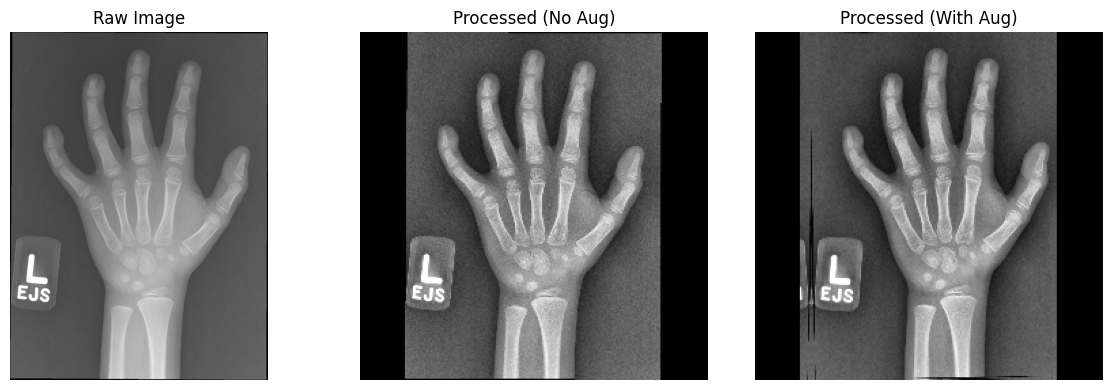

Mean absolute differences between augmented runs:
Run 0 vs 1: 0.0917
Run 1 vs 2: 0.1283
Run 2 vs 3: 0.1120
Run 3 vs 4: 0.1053
✅ Augmentation variability confirmed.
✅ Dataset batch structure is correct.
Images batch: (16, 256, 256, 3)
Genders: (16,)
Ages: (16,)


In [17]:
sample_image = train_df.iloc[0]["path"]

test_pipeline_visual_sanity(sample_image)
test_augmentation_variability(sample_image)
test_dataset_output(train_ds)


# Model Creation Helper Function

In [ ]:
# Builds an ensemble CNN model with a InceptionV3 & ResNet50 backbones and embedding gender layer
def create_model():
    img_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
    gender_input = Input(shape=(1,), name='gender_input')
    
    # Load the pre-trained InceptionV3 model using imagenet weights for recognizing shapes/edges
    # Also we remove original classification top layer
    inception = InceptionV3(weights='imagenet', include_top=False, input_tensor=img_input)

    # We unfreeze the inception backbone to fine-tune it on our X-ray images
    inception.trainable = True
    
    # Rename layers to avoid conflicts
    for layer in inception.layers: 
        layer._name = "inc_" + layer.name 

    # Global Average Pooling condenses the complex feature maps into a single vector
    x1 = GlobalAveragePooling2D()(inception.output)
    
    # Same steps for ResNet50 model
    resnet = ResNet50(weights='imagenet', include_top=False, input_tensor=img_input)
    resnet.trainable = True
    for layer in resnet.layers: 
        layer._name = "res_" + layer.name
    x2 = GlobalAveragePooling2D()(resnet.output)
    
    # Combine visual features from both models
    x_visual = Concatenate()([x1, x2])
    
    # Gender Embedding as we treat gender as a learnable feature to learn difference in male/female growth patterns
    x_gender = Embedding(input_dim=2, output_dim=16)(gender_input) # Turns the simple 0/1 gender input into a rich vector of size 16
    x_gender = Flatten()(x_gender)
    x_gender = Dense(32, activation='relu')(x_gender) # Small dense layer to process the gender embedding
    
    # Concatenate the image features and gender features into one long vector
    x = Concatenate()([x_visual, x_gender])
    
    # Layer 1: Reduce to 512 features, use Dropout to prevent overfitting
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x) 
    
    # Layer 2: Reduce to 128 features
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    
    # Output Layer: Single neuron with no activation, this predicts the exact normalized age value
    output = Dense(1, activation='linear', dtype='float32', name='age_output')(x)
    
    # Compile the final model
    model = models.Model(inputs=[img_input, gender_input], outputs=output)
    
    return model

# Model Training Looping Over The K-Folds

In [20]:
kf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fold_scores = []
best_mae = float('inf')
best_weights_path = "best_ensemble.weights.h5"

print(f"\nSTARTING {K_FOLDS}-FOLD ENSEMBLE TRAINING")

for fold, (train_idx, val_idx) in enumerate(kf.split(train_df, train_df["strata"])):
    print(f"\nFOLD {fold+1}/{K_FOLDS}")
    
    # Create pipelines for training and validation
    ds_train = create_dataset(train_df.iloc[train_idx], training=True)
    ds_val   = create_dataset(train_df.iloc[val_idx], training=False)
    
    # Initialize the model
    model = create_model()
    
    # Define AdamW Optimizer
    optimizer = AdamW(learning_rate=1e-4, weight_decay=1e-5)
    
    # Define Huber Loss Function which is robust to outliers/noisy labels 
    loss_fn = Huber(delta=1.0)
    
    # Compile model while maintaining mean absolute error metric
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=['mae'])
    
    # Callbacks
    callbacks = [
        # Lowers learning rate if model stops improving
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1), 
        # Stops & Restores best model weights if no improvements occur
        EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)
    ]
    
    # Train our model
    history = model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_PER_FOLD, callbacks=callbacks, verbose=1)
    
    # Evaluate current fold
    val_loss, val_mae_norm = model.evaluate(ds_val, verbose=0)
    val_mae = val_mae_norm * age_std
    print(f"Fold {fold+1} MAE: {val_mae:.2f} months")
    fold_scores.append(val_mae)
    
    # Save Best Model Logic
    if val_mae < best_mae:
        best_mae = val_mae
        model.save_weights(best_weights_path)

print(f"\nCross-Validation Mean MAE: {np.mean(fold_scores):.2f} months")


STARTING 5-FOLD ENSEMBLE TRAINING

FOLD 1/5
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8


I0000 00:00:1767220926.332127     126 service.cc:152] XLA service 0x793d58002bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767220926.332171     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767220926.332177     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767220938.765356     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1767220994.674426     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


536/536 ━━━━━━━━━━━━━━━━━━━━ 555s 736ms/step - loss: 0.2334 - mae: 0.5484 - val_loss: 0.3035 - val_mae: 0.6654 - learning_rate: 1.0000e-04
Epoch 2/8
536/536 ━━━━━━━━━━━━━━━━━━━━ 335s 569ms/step - loss: 0.0899 - mae: 0.3372 - val_loss: 0.0686 - val_mae: 0.2913 - learning_rate: 1.0000e-04
Epoch 3/8
536/536 ━━━━━━━━━━━━━━━━━━━━ 333s 566ms/step - loss: 0.0614 - mae: 0.2720 - val_loss: 0.0427 - val_mae: 0.2270 - learning_rate: 1.0000e-04
Epoch 4/8
536/536 ━━━━━━━━━━━━━━━━━━━━ 381s 565ms/step - loss: 0.0529 - mae: 0.2530 - val_loss: 0.0359 - val_mae: 0.2096 - learning_rate: 1.0000e-04
Epoch 5/8
536/536 ━━━━━━━━━━━━━━━━━━━━ 333s 567ms/step - loss: 0.0455 - mae: 0.2368 - val_loss: 0.0417 - val_mae: 0.2235 - learning_rate: 1.0000e-04
Epoch 6/8
536/536 ━━━━━━━━━━━━━━━━━━━━ 333s 566ms/step - loss: 0.0461 - mae: 0.2352 - val_loss: 0.0702 - val_mae: 0.2982 - learning_rate: 1.0000e-04
Epoch 7/8
536/536 ━━━━━━━━━━━━━━━━━━━━ 382s 566ms/step - loss: 0.0456 - mae: 0.2347 - val_loss: 0.0353 - val_mae: 0.

'\n# Main Model Creation & Training Loop\n# Initialize the model\nmodel = create_model(backbone_name=\'InceptionV3\')\n\n# Define AdamW Optimizer\noptimizer = AdamW(learning_rate=1e-4, weight_decay=1e-5)\n\n# Define Huber Loss Function which is robust to outliers/noisy labels \nloss_fn = Huber(delta=1.0)\n\n# Compile model while maintaining mean absolute error metric\nmodel.compile(optimizer=optimizer, loss=loss_fn, metrics=[\'mae\'])\n\n# Training our model\nhistory = model.fit(\ntrain_ds,\nvalidation_data=val_ds,\nepochs=10,\ncallbacks=\n[\n  tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_mae"), # Saves best model to avoid overfitting model being the result\n  tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5) # Lowers learning rate if model stops improving\n]\n)\n\n# Test our model and visualize the results\ntrue_ages, pred_ages, final_mae = evaluate_model(model, val_ds, age_std, age_mean)\nplot_prediction_resul

# Evaluating Model Results On Test Data

In [26]:
# Calculates the best performane metrics on the test dataset
def evaluate_model(model, dataset, age_std, age_mean):
    print("Generating Predictions For Test Dataset")
    
    # Get predictions from the model
    normalized_preds = model.predict(dataset, verbose=1)
    
    # Extract true labels (ages) from the dataset, iterate to extract the labels because they are batched
    normalized_labels = []
    for _, labels in dataset:
        normalized_labels.extend(labels.numpy())
    normalized_labels = np.array(normalized_labels)
    
    # Denormalize ages of both predictions and ground truth labels to get back to months
    pred_months = denormalize_age(normalized_preds.flatten(), age_std, age_mean)
    true_months = denormalize_age(normalized_labels, age_std, age_mean)
    
    # Calculate Important Performance Metrics
    mae = mean_absolute_error(true_months, pred_months)
    rmse = np.sqrt(mean_squared_error(true_months, pred_months))
    r2 = r2_score(true_months, pred_months)

    # To Check Prediction Accuracy, we view % of patients predicted within X months
    diff = np.abs(pred_months - true_months)
    within_6m  = (diff <= 6).mean() * 100
    within_1y  = (diff <= 12).mean() * 100
    within_2y  = (diff <= 24).mean() * 100

    # Printing model results
    print("\n" + "="*50)
    print(f"PERFORMANCE METRICS:")
    print("="*50)
    print(f"   MAE (Mean Absolute Error):     {mae:.2f} months")
    print(f"   RMSE (Root Mean Sq Error):     {rmse:.2f} months")
    print(f"   R² Score:                      {r2:.4f}")
    print("-" * 50)
    print(f"   Percentage Of Correct Age Predictions:")
    print(f"   Within ±6 months:              {within_6m:.2f}%")
    print(f"   Within ±1 year:                {within_1y:.2f}%")
    print(f"   Within ±2 years:               {within_2y:.2f}%")
    print("="*50)
    
    return true_months, pred_months, mae

# Final Test Evaluation
print("\nEvaluating Best Model on Test Set...")
final_model = create_model()
final_model.load_weights(best_weights_path)

ds_test = create_dataset(test_df, training=False)
y_true, y_pred, final_mae = evaluate_model(final_model, ds_test, age_std, age_mean)


Evaluating Best Model on Test Set...
Generating Predictions For Test Dataset
119/119 ━━━━━━━━━━━━━━━━━━━━ 49s 330ms/step

PERFORMANCE METRICS:
   MAE (Mean Absolute Error):     8.70 months
   RMSE (Root Mean Sq Error):     11.53 months
   R² Score:                      0.9217
--------------------------------------------------
   Percentage Of Correct Age Predictions:
   Within ±6 months:              44.61%
   Within ±1 year:                74.95%
   Within ±2 years:               95.45%


# Visualization Of Model Results

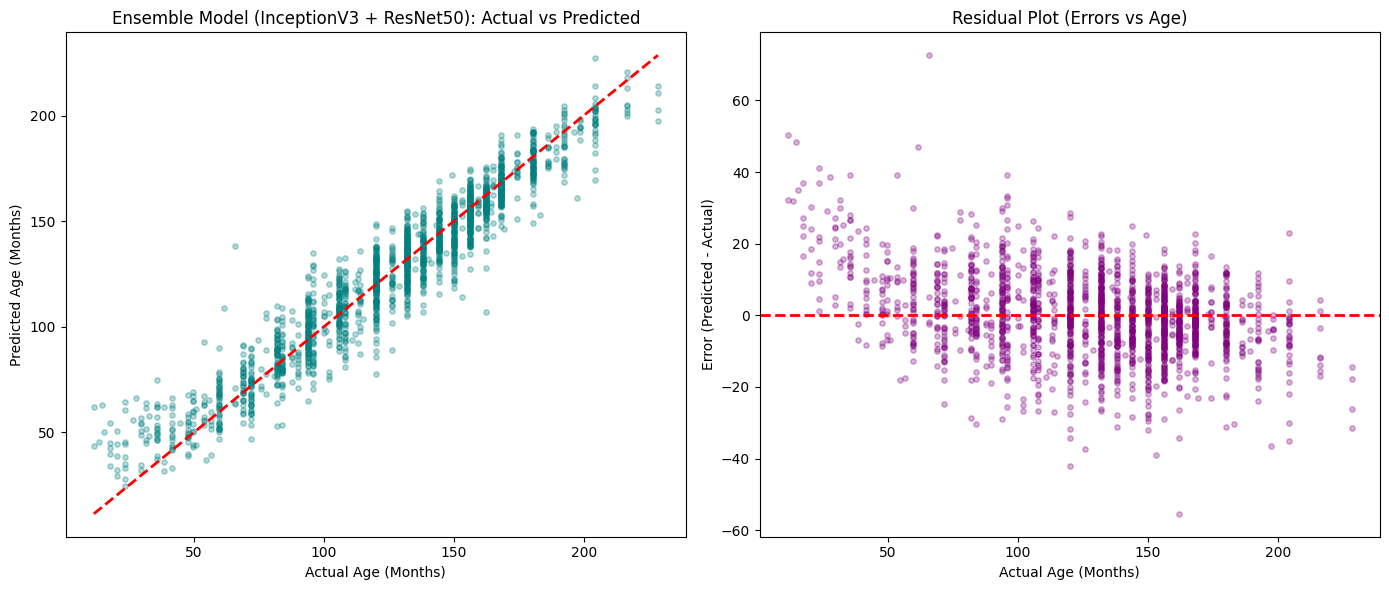

In [28]:
def plot_results(y_true, y_pred, title="Model Results"):
    plt.figure(figsize=(14, 6))
    
    # Scatter Plot
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.3, color='teal', s=15)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2) # Red line represents perfect prediction
    plt.title(f"{title}: Actual vs Predicted")
    plt.xlabel("Actual Age (Months)")
    plt.ylabel("Predicted Age (Months)")
    
    # Residual Plot
    residuals = y_pred - y_true
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_true, residuals, alpha=0.3, color='purple', s=15)
    plt.axhline(0, color='red', linestyle='--', lw=2) # The zero error line
    plt.title("Residual Plot (Errors vs Age)")
    plt.xlabel("Actual Age (Months)")
    plt.ylabel("Error (Predicted - Actual)")
    
    plt.tight_layout()
    plt.show()

# Visualize the results
plot_results(y_true, y_pred, title="Ensemble Model (InceptionV3 + ResNet50)")